## 📁 Código-fonte disponível

**Repositório GitHub:** [https://github.com/PedroRyanMagalhaes/IndiciumAI](https://github.com/PedroRyanMagalhaes/IndiciumAI)

---

In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Configuração global para gráficos estáticos
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})


In [2]:
conn = sqlite3.connect('northwind.db')

caminho_dados = 'data/'

arquivos = [
    'categories', 'customer_customer_demo', 'customer_demographics', 
    'customers', 'employee_territories', 'employees', 'order_details', 
    'orders', 'products', 'region', 'shippers', 'suppliers', 
    'territories', 'us_states'
]

### O Fim das Planilhas Manuais

**O Problema:** A dependência de planilhas criava gargalos.

**A Solução:** Toda a manipulação, desde a extração até o cálculo do Ticket Médio, foi automatizada utilizando SQL e Python. Isso significa que este relatório não é estático; ele é um script reprodutível. À medida que novos dados entram no banco, basta reexecutar o processo e os KPIs e gráficos são atualizados instantaneamente, eliminando o trabalho manual e o risco de erros de digitação.

In [3]:
for arquivo in arquivos:
    caminho_completo = f'{caminho_dados}{arquivo}.csv'
    df = pd.read_csv(caminho_completo, sep=';')
    df.to_sql(arquivo, conn, if_exists='replace', index=False)
print(f'{arquivos} importados com sucesso!')

['categories', 'customer_customer_demo', 'customer_demographics', 'customers', 'employee_territories', 'employees', 'order_details', 'orders', 'products', 'region', 'shippers', 'suppliers', 'territories', 'us_states'] importados com sucesso!


In [4]:
print("--- Relatório de Auditoria de Dados (Raw Data) ---")

todas_tabelas = [
    'categories', 'customer_customer_demo', 'customer_demographics', 
    'customers', 'employee_territories', 'employees', 'order_details', 
    'orders', 'products', 'region', 'shippers', 'suppliers', 
    'territories', 'us_states'
]

for tabela in todas_tabelas:
    df_temp = pd.read_sql_query(f"SELECT * FROM {tabela}", conn)
    
    total_linhas = len(df_temp)
    total_nulos = df_temp.isnull().sum().sum()
    
    if total_linhas == 0:
        status = "❌ Tabela Vazia!"
    elif total_nulos == 0:
        status = "✅ Zero Nulos"
    else:
        status = f"Atenção: {total_nulos} valores nulos encontrados"
        
    nome_tabela = f"'{tabela.upper()}'".ljust(25)
    print(f"Tabela {nome_tabela} : {total_linhas} registros | Status: {status}")

--- Relatório de Auditoria de Dados (Raw Data) ---
Tabela 'CATEGORIES'              : 8 registros | Status: ✅ Zero Nulos
Tabela 'CUSTOMER_CUSTOMER_DEMO'  : 0 registros | Status: ❌ Tabela Vazia!
Tabela 'CUSTOMER_DEMOGRAPHICS'   : 0 registros | Status: ❌ Tabela Vazia!
Tabela 'CUSTOMERS'               : 91 registros | Status: Atenção: 83 valores nulos encontrados
Tabela 'EMPLOYEE_TERRITORIES'    : 49 registros | Status: ✅ Zero Nulos
Tabela 'EMPLOYEES'               : 9 registros | Status: Atenção: 5 valores nulos encontrados
Tabela 'ORDER_DETAILS'           : 2155 registros | Status: ✅ Zero Nulos
Tabela 'ORDERS'                  : 830 registros | Status: Atenção: 547 valores nulos encontrados
Tabela 'PRODUCTS'                : 77 registros | Status: ✅ Zero Nulos
Tabela 'REGION'                  : 4 registros | Status: ✅ Zero Nulos
Tabela 'SHIPPERS'                : 6 registros | Status: ✅ Zero Nulos
Tabela 'SUPPLIERS'               : 29 registros | Status: Atenção: 60 valores nulos encont

### *Single Source of Truth* (Fonte Única da Verdade)

**O Desafio:** Atualmente, a Northwind sofre com dados de diferentes áreas que não batem durante as reuniões. Isso ocorre pela falta de uma centralização das regras de negócio.

**A Solução Técnica:** Para resolver isso de forma escalável, o primeiro passo é criar uma **Tabela Fato de Vendas**. Essa tabela une os cabeçalhos dos pedidos (`orders`) com os itens comprados (`order_details`) e já calcula o **Valor Total Faturado** por item (descontando promoções). 

In [5]:
query_fato_vendas = """
SELECT 
    o.order_id,
    o.customer_id,
    o.employee_id,
    DATE(o.order_date) AS data_pedido,
    od.product_id,
    od.quantity AS quantidade,
    od.unit_price AS preco_unitario,
    od.discount AS desconto,
    (od.quantity * od.unit_price * (1 - od.discount)) AS valor_total_item
FROM orders o
JOIN order_details od ON o.order_id = od.order_id
"""

In [6]:
df_fato_vendas = pd.read_sql_query(query_fato_vendas, conn)
display(df_fato_vendas.head())

,order_id,customer_id,employee_id,data_pedido,product_id,quantidade,preco_unitario,desconto,valor_total_item
0,10248,VINET,5,1996-07-04,11,12,14.0,0.0,168.0
1,10248,VINET,5,1996-07-04,42,10,9.8,0.0,98.0
2,10248,VINET,5,1996-07-04,72,5,34.8,0.0,174.0
3,10249,TOMSP,6,1996-07-05,14,9,18.6,0.0,167.4
4,10249,TOMSP,6,1996-07-05,51,40,42.4,0.0,1696.0


### Objetivo Estratégico: Análise do Ticket Médio e Faturamento

**O Desafio:** A diretoria definiu como meta o aumento do ticket médio.

**A Solução Analítica:** Utilizando a nossa Fonte Única da Verdade, calculamos o Ticket Médio Global (Faturamento Total / Quantidade de Pedidos) e a sua evolução mensal. Isso nos permite identificar se o valor médio gasto pelos clientes está crescendo organicamente ou se está estagnado, além de dar ao CEO a visão financeira consolidada que faltava.

In [7]:
query_ticket_medio = """
WITH metricas_pedidos AS (
    SELECT 
        o.order_id,
        STRFTIME('%Y-%m', o.order_date) AS mes_ano,
        SUM(od.quantity * od.unit_price * (1 - od.discount)) AS valor_total_pedido
    FROM orders o
    JOIN order_details od ON o.order_id = od.order_id
    GROUP BY o.order_id, mes_ano
)
SELECT 
    mes_ano,
    COUNT(DISTINCT order_id) AS total_pedidos,
    ROUND(SUM(valor_total_pedido), 2) AS faturamento_mensal,
    ROUND(SUM(valor_total_pedido) / COUNT(DISTINCT order_id), 2) AS ticket_medio
FROM metricas_pedidos
GROUP BY mes_ano
ORDER BY mes_ano;
"""

In [8]:
df_ticket_medio = pd.read_sql_query(query_ticket_medio, conn)

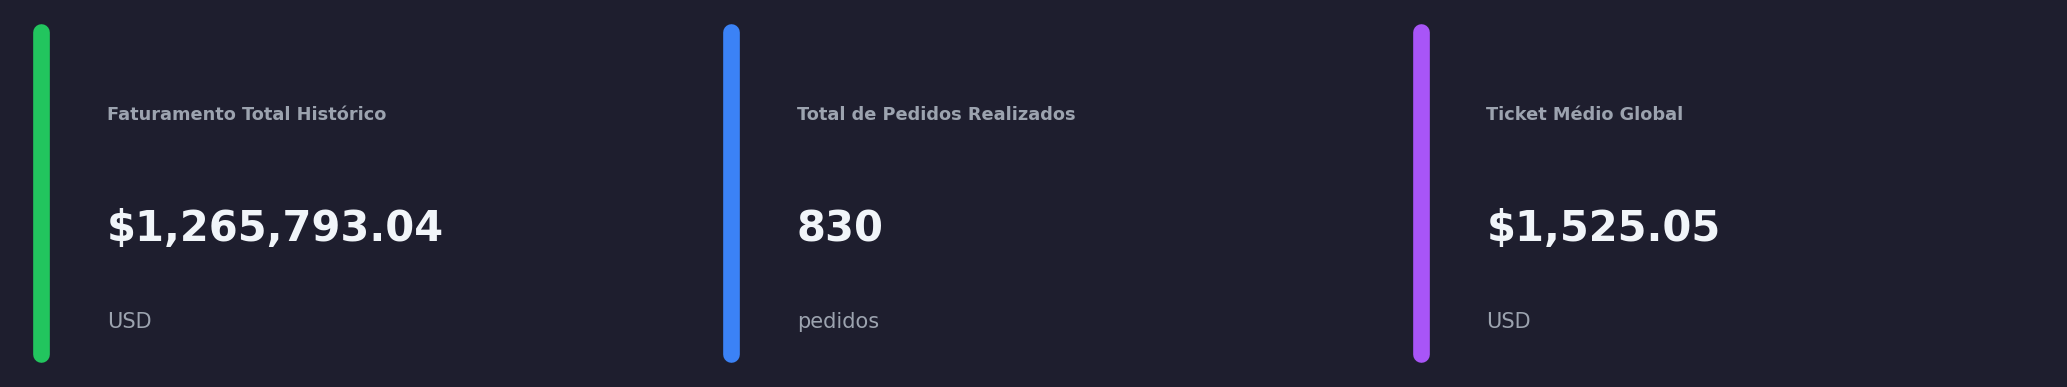

In [9]:
from IPython.display import display

faturamento_total = df_ticket_medio['faturamento_mensal'].sum()
total_pedidos_global = df_ticket_medio['total_pedidos'].sum()
ticket_medio_global = faturamento_total / total_pedidos_global

kpis = [
    {'label': 'Faturamento Total Histórico', 'value': f'${faturamento_total:,.2f}', 'unit': 'USD',     'color': '#22c55e'},
    {'label': 'Total de Pedidos Realizados',  'value': f'{total_pedidos_global:,}',  'unit': 'pedidos', 'color': '#3b82f6'},
    {'label': 'Ticket Médio Global',           'value': f'${ticket_medio_global:,.2f}','unit': 'USD',   'color': '#a855f7'},
]

fig, axes = plt.subplots(1, 3, figsize=(14, 2.8))
fig.patch.set_facecolor('#1e1e2e')

for ax, kpi in zip(axes, kpis):
    ax.set_facecolor('#2a2a3e')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.axvline(x=0.04, ymin=0.05, ymax=0.95, color=kpi['color'], linewidth=8, solid_capstyle='round')
    ax.text(0.14, 0.72, kpi['label'], fontsize=8.5, color='#9ca3af',
            ha='left', va='center', transform=ax.transAxes, fontweight='bold')
    ax.text(0.14, 0.40, kpi['value'], fontsize=20, color='#f1f5f9',
            ha='left', va='center', transform=ax.transAxes, fontweight='bold')
    ax.text(0.14, 0.14, kpi['unit'], fontsize=10, color='#9ca3af',
            ha='left', va='center', transform=ax.transAxes)

plt.tight_layout(pad=1.5)
plt.show()


### Visualização de Desempenho: Evolução do Ticket Médio

**O Foco no Comercial:** A diretoria comercial precisa acompanhar a saúde das vendas de forma clara. O gráfico abaixo ilustra a variação do Ticket Médio ao longo dos meses. 

**Insight Preliminar:** Ao visualizar essa linha do tempo, podemos identificar sazonalidades e avaliar se o valor médio dos pedidos está estagnado, o que justificaria uma nova campanha de *cross-sell* para incentivar compras casadas.

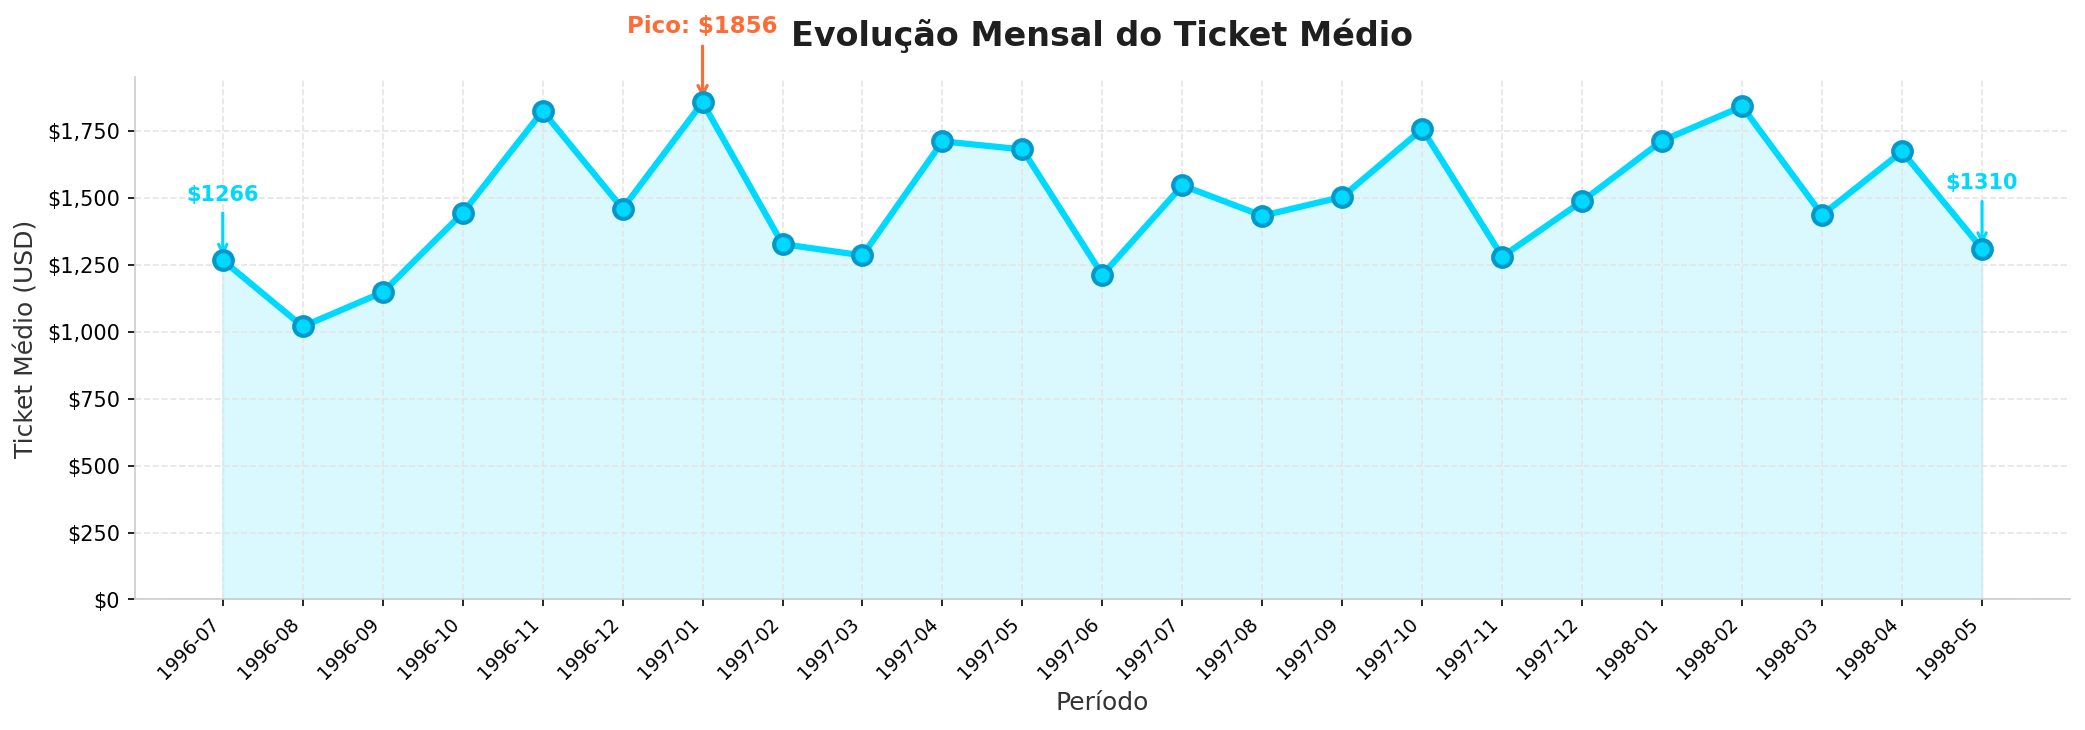

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x = list(range(len(df_ticket_medio)))
y = df_ticket_medio['ticket_medio'].values
labels = df_ticket_medio['mes_ano'].values

ax.fill_between(x, y, alpha=0.15, color='#00D9FF')
ax.plot(x, y, color='#00D9FF', linewidth=3, zorder=3)
ax.scatter(x, y, color='#00D9FF', s=80, zorder=4, edgecolors='#0099CC', linewidths=2)

# primeiro ponto
ax.annotate(f"${y[0]:.0f}",
            xy=(0, y[0]), xytext=(0, y[0] + y.max() * 0.12),
            fontsize=10, color='#00D9FF', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='#00D9FF', lw=1.5))

# pico
max_idx = int(np.argmax(y))
ax.annotate(f"Pico: ${y[max_idx]:.0f}",
            xy=(max_idx, y[max_idx]), xytext=(max_idx, y[max_idx] + y.max() * 0.14),
            fontsize=11, color='#FF6B35', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='#FF6B35', lw=1.5))

# último ponto
ax.annotate(f"${y[-1]:.0f}",
            xy=(len(x) - 1, y[-1]), xytext=(len(x) - 1, y[-1] + y.max() * 0.12),
            fontsize=10, color='#00D9FF', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='#00D9FF', lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_ylim(0)
ax.set_xlabel('Período', fontsize=12, color='#333')
ax.set_ylabel('Ticket Médio (USD)', fontsize=12, color='#333')
ax.set_title('Evolução Mensal do Ticket Médio', fontsize=16, fontweight='bold',
             color='#1f1f1f', pad=15)
ax.grid(True, color='#E5E5E5', linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()


### 💡 Insights do Dashboard de Performance

**Categorias:** Identificar quais linhas de produtos geram mais receita permite otimizar estoque e direcionar campanhas de marketing para as categorias de maior valor.

**Geografia:** Conhecer os mercados mais rentáveis ajuda a definir prioridades de expansão, logística e estratégias de precificação regional.

**Vendedores:** Reconhecer os top performers possibilita replicar suas melhores práticas através de treinamentos e programas de mentoria, além de fundamentar políticas de bonificação baseadas em dados.

**Ação Recomendada:** Cruzar essas três dimensões (ex: quais vendedores vendem mais em quais países e categorias) pode revelar oportunidades ocultas de otimização comercial.

In [11]:
#Top 5 Categorias por Faturamento
query_categorias = """
SELECT 
    c.category_name as categoria,
    ROUND(SUM(od.quantity * od.unit_price * (1 - od.discount)), 2) as faturamento
FROM order_details od
JOIN products p ON od.product_id = p.product_id
JOIN categories c ON p.category_id = c.category_id
JOIN orders o ON od.order_id = o.order_id
GROUP BY c.category_name
ORDER BY faturamento DESC
LIMIT 5
"""

#Top 5 Países por Faturamento
query_paises = """
SELECT 
    o.ship_country as pais,
    ROUND(SUM(od.quantity * od.unit_price * (1 - od.discount)), 2) as faturamento
FROM orders o
JOIN order_details od ON o.order_id = od.order_id
GROUP BY o.ship_country
ORDER BY faturamento DESC
LIMIT 5
"""

#Top 5 Vendedores por Faturamento
query_vendedores = """
SELECT 
    e.first_name || ' ' || e.last_name as vendedor,
    ROUND(SUM(od.quantity * od.unit_price * (1 - od.discount)), 2) as faturamento
FROM orders o
JOIN order_details od ON o.order_id = od.order_id
JOIN employees e ON o.employee_id = e.employee_id
GROUP BY vendedor
ORDER BY faturamento DESC
LIMIT 5
"""

df_categorias = pd.read_sql_query(query_categorias, conn)
df_paises = pd.read_sql_query(query_paises, conn)
df_vendedores = pd.read_sql_query(query_vendedores, conn)


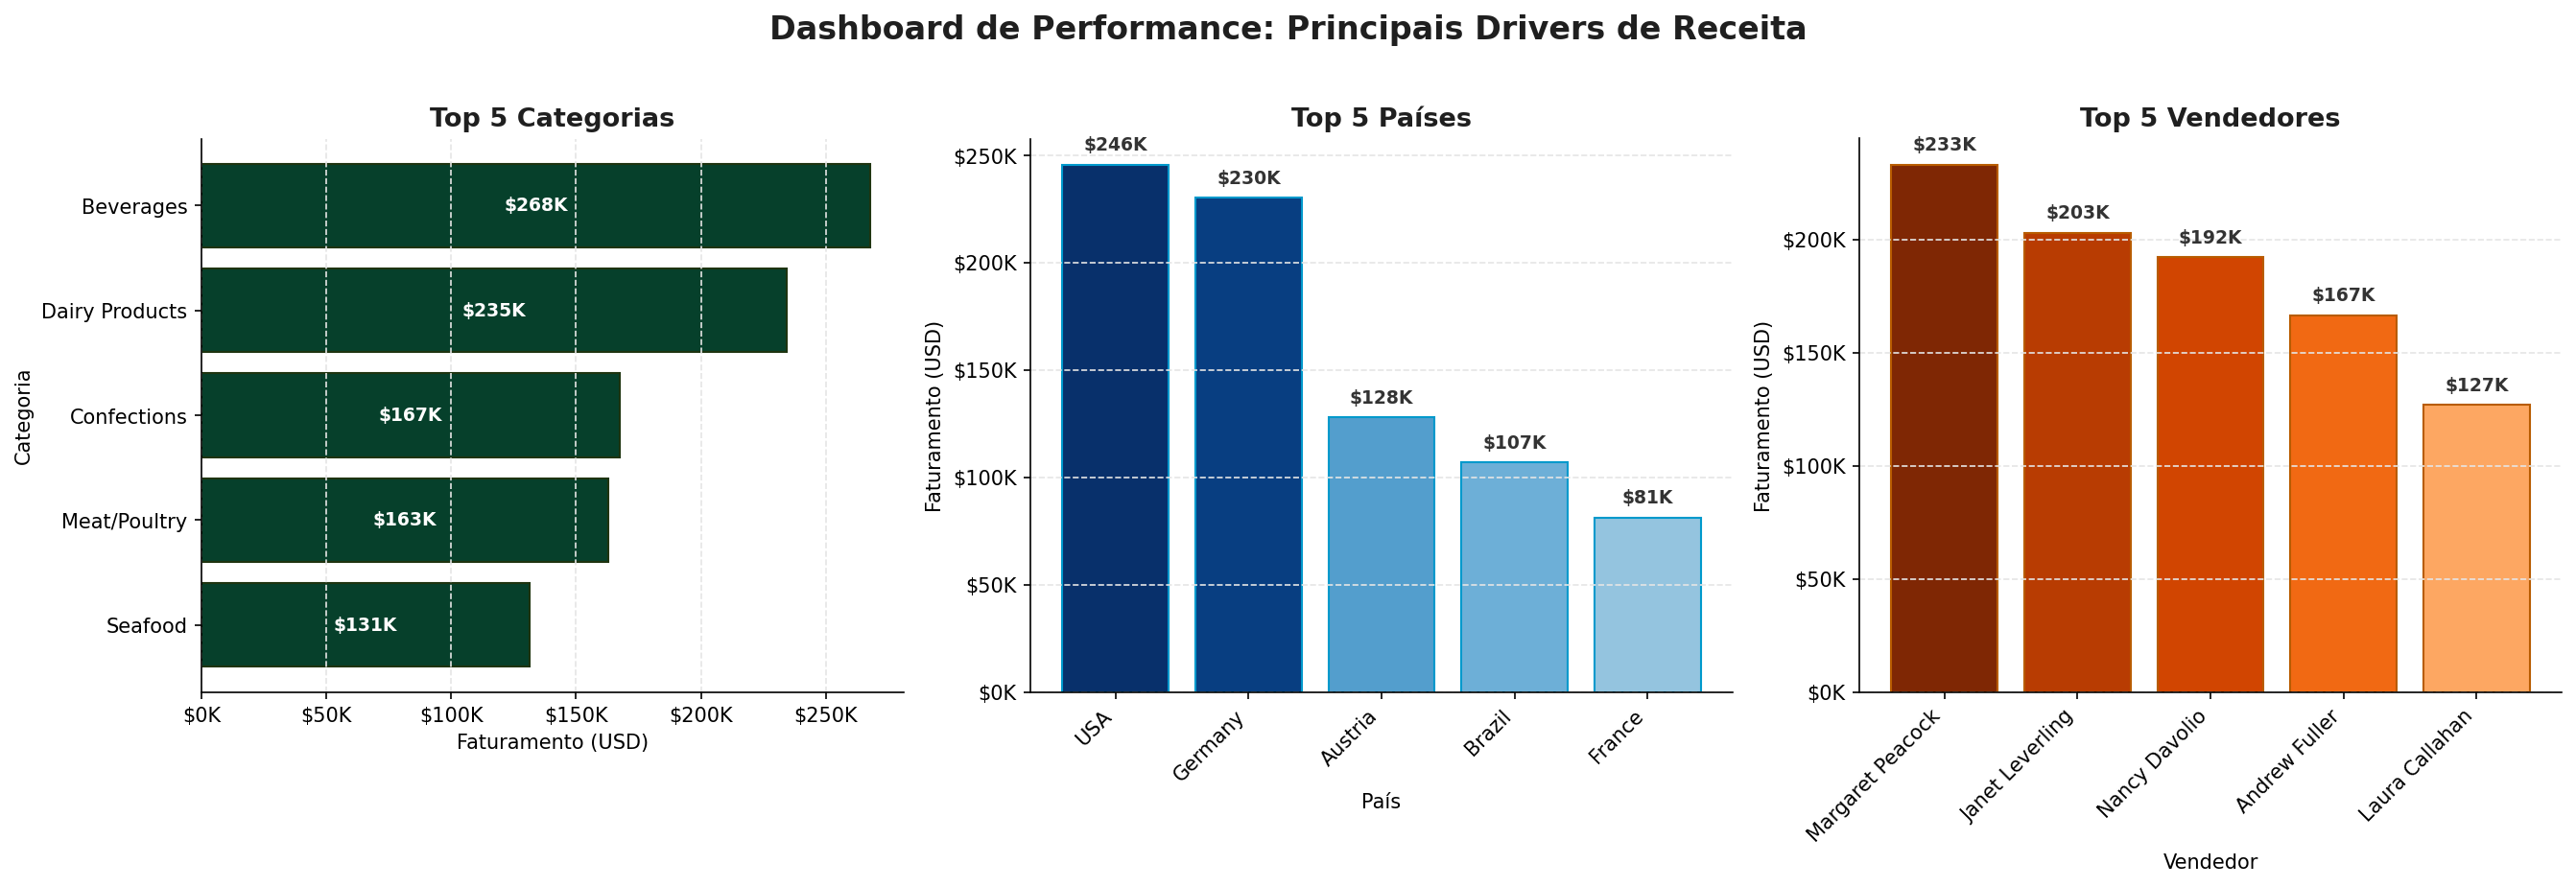

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

#Top 5 Categorias
ax1 = axes[0]
cats     = df_categorias['categoria'][::-1].reset_index(drop=True)
fat_cats = df_categorias['faturamento'][::-1].reset_index(drop=True)
bars1 = ax1.barh(cats, fat_cats, color='#06402B', edgecolor='#1E3410', linewidth=1)
for bar, val in zip(bars1, fat_cats):
    ax1.text(bar.get_width() * 0.5, bar.get_y() + bar.get_height() / 2,
             f'${val/1000:.0f}K', va='center', ha='center',
             color='white', fontsize=9, fontweight='bold')

ax1.set_title('Top 5 Categorias', fontsize=13, fontweight='bold', color='#1f1f1f')
ax1.set_xlabel('Faturamento (USD)', fontsize=10)
ax1.set_ylabel('Categoria', fontsize=10)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax1.grid(axis='x', color='#E5E5E5', linestyle='--', linewidth=0.8)
ax1.set_facecolor('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#Top 5 Países
ax2 = axes[1]
norm_p = plt.Normalize(df_paises['faturamento'].min(), df_paises['faturamento'].max())
cols_p = cm.Blues(norm_p(df_paises['faturamento'].values) * 0.6 + 0.4)
bars2  = ax2.bar(df_paises['pais'], df_paises['faturamento'], color=cols_p,
                 edgecolor='#0099CC', linewidth=1)

for bar, val in zip(bars2, df_paises['faturamento']):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + df_paises['faturamento'].max() * 0.02,
             f'${val/1000:.0f}K', va='bottom', ha='center',
             color='#333', fontsize=9, fontweight='bold')

ax2.set_title('Top 5 Países', fontsize=13, fontweight='bold', color='#1f1f1f')
ax2.set_xlabel('País', fontsize=10)
ax2.set_ylabel('Faturamento (USD)', fontsize=10)
ax2.set_xticks(range(len(df_paises['pais'])))
ax2.set_xticklabels(df_paises['pais'], rotation=45, ha='right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax2.grid(axis='y', color='#E5E5E5', linestyle='--', linewidth=0.8)
ax2.set_facecolor('white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

#Top 5 Vendedores
ax3 = axes[2]
norm_v = plt.Normalize(df_vendedores['faturamento'].min(), df_vendedores['faturamento'].max())
cols_v = cm.Oranges(norm_v(df_vendedores['faturamento'].values) * 0.6 + 0.4)
bars3  = ax3.bar(df_vendedores['vendedor'], df_vendedores['faturamento'], color=cols_v,
                 edgecolor='#B85C00', linewidth=1)

for bar, val in zip(bars3, df_vendedores['faturamento']):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + df_vendedores['faturamento'].max() * 0.02,
             f'${val/1000:.0f}K', va='bottom', ha='center',
             color='#333', fontsize=9, fontweight='bold')

ax3.set_title('Top 5 Vendedores', fontsize=13, fontweight='bold', color='#1f1f1f')
ax3.set_xlabel('Vendedor', fontsize=10)
ax3.set_ylabel('Faturamento (USD)', fontsize=10)
ax3.set_xticks(range(len(df_vendedores['vendedor'])))
ax3.set_xticklabels(df_vendedores['vendedor'], rotation=45, ha='right')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax3.grid(axis='y', color='#E5E5E5', linestyle='--', linewidth=0.8)
ax3.set_facecolor('white')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

fig.suptitle('Dashboard de Performance: Principais Drivers de Receita',
             fontsize=16, fontweight='bold', color='#1f1f1f', y=1.02)
plt.tight_layout()
plt.show()


### Análise e Redução de Churn

**O Desafio:** A diretoria definiu a redução do *churn* (evasão de clientes) como prioridade. Como a Northwind Traders não atua com um modelo de assinatura, precisamos definir matematicamente o que significa "perder um cliente".

**A Regra de Negócio (Visão Analítica):** Levando em consideração que o core business da empresa é a venda de bens de consumo rápido (alimentos, bebidas e utilidades domésticas), o ciclo de recompra é curto. Portanto, foi definido que **um cliente é considerado em "Churn" se a sua última compra ocorreu há mais de 3 meses (90 dias)** em relação à data atual do sistema.

**A Solução Técnica:** Utilizando SQL, calculamos a data da última compra de cada cliente e a comparamos com a data da última transação registrada na empresa, segmentando a base entre "Ativos" e "Churn".

In [13]:
query_churn = """
WITH data_sistema AS (
    SELECT MAX(DATE(order_date)) as data_atual FROM orders
),
ultima_compra_cliente AS (
    SELECT 
        customer_id, 
        MAX(DATE(order_date)) as ultima_compra
    FROM orders
    GROUP BY customer_id
),
classificacao_clientes AS (
    SELECT 
        u.customer_id,
        u.ultima_compra,
        d.data_atual,
        CAST(JULIANDAY(d.data_atual) - JULIANDAY(u.ultima_compra) AS INTEGER) AS dias_inativo,
        CASE 
            WHEN CAST(JULIANDAY(d.data_atual) - JULIANDAY(u.ultima_compra) AS INTEGER) > 90 THEN 'Churn'
            ELSE 'Ativo'
        END AS status
    FROM ultima_compra_cliente u
    CROSS JOIN data_sistema d
)
SELECT 
    status,
    COUNT(customer_id) AS total_clientes,
    ROUND(COUNT(customer_id) * 100.0 / (SELECT COUNT(*) FROM classificacao_clientes), 2) AS percentual
FROM classificacao_clientes
GROUP BY status;
"""

In [14]:
df_churn = pd.read_sql_query(query_churn, conn)

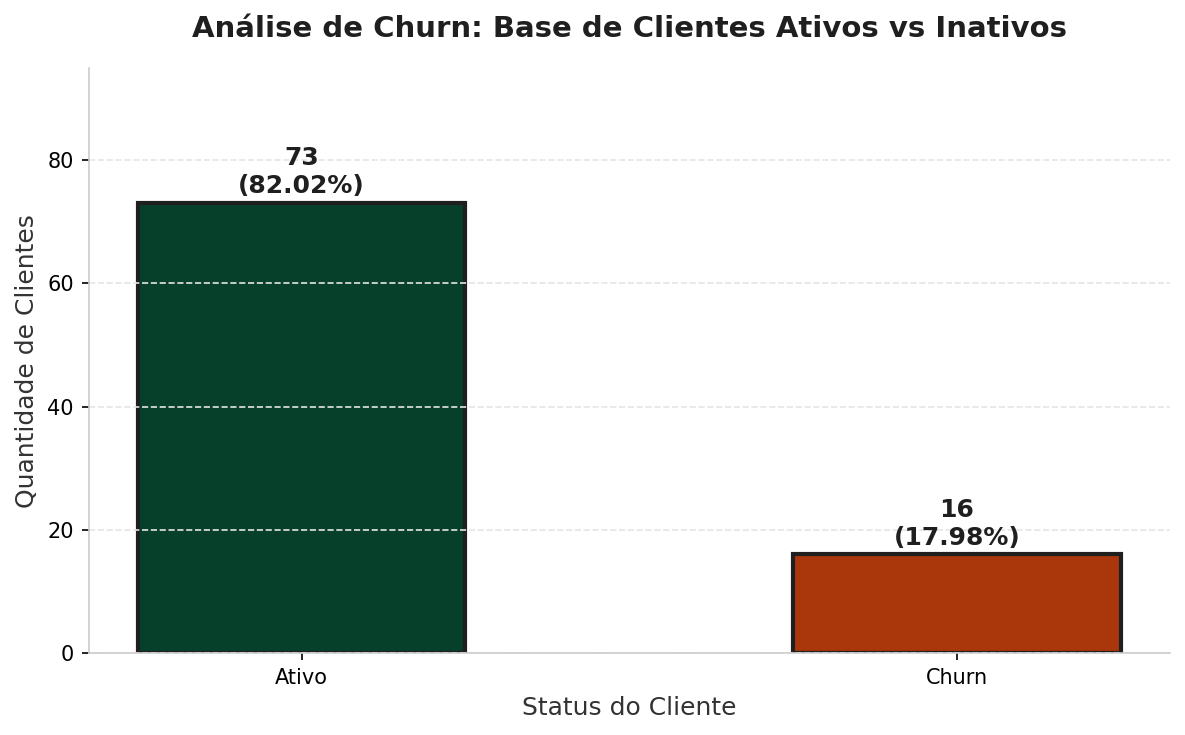

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors = ['#06402B', "#AA360C"]
bars = ax.bar(df_churn['status'], df_churn['total_clientes'],
              color=colors, edgecolor='#1f1f1f', linewidth=2, width=0.5)

for bar, row in zip(bars, df_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{row.total_clientes}\n({row.percentual}%)",
            va='bottom', ha='center', fontsize=12, fontweight='bold', color='#1f1f1f')

ax.set_xlabel('Status do Cliente', fontsize=12, color='#333')
ax.set_ylabel('Quantidade de Clientes', fontsize=12, color='#333')
ax.set_title('Análise de Churn: Base de Clientes Ativos vs Inativos',
             fontsize=14, fontweight='bold', color='#1f1f1f', pad=15)
ax.set_ylim(0, df_churn['total_clientes'].max() * 1.3)
ax.grid(axis='y', color='#E5E5E5', linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()


### Plano de Ação (Para Inovação & Comercial)

Com uma taxa de *Churn* de aproximadamente **18%** (16 clientes inativos na janela de 90 dias) e a necessidade de aumentar o Ticket Médio, sugiro as seguintes frentes de inovação *data-driven*:

1. **Campanha de Reativação (Win-back):** O time comercial agora possui a lista exata dos 16 clientes inativos. Sugerimos uma abordagem focada e personalizada, oferecendo condições especiais (como frete grátis ou descontos nas categorias que eles mais compravam) para recuperar essa receita adormecida.
2. **Combos Inteligentes (Cross-sell):** Para maximizar o valor dos **73 clientes ativos**, podemos utilizar o banco de dados para estruturar uma *Market Basket Analysis* (Análise de Cesta de Compras), descobrindo quais produtos saem juntos com frequência. Com isso, criamos "Combos" estratégicos, forçando o aumento orgânico do Ticket Médio.

---

### 🏛️ Recomendação de Arquitetura (Para a TI)

Entendemos os receios históricos da TI com projetos de BI caros e demorados. Para garantir que os dados "sempre batam" sem estourar o orçamento, recomendamos a adoção do **Modern Data Stack (MDS)**:

* **Ingestão e Armazenamento:** Manter o banco PostgreSQL em nuvem como nosso *Data Warehouse* central. Utilizar ferramentas open-source ou de baixo custo para centralizar os dados do ERP, Salesforce e ContaAzul.
* **Transformação (O Segredo):** Utilizar o **dbt (data build tool)**. Em vez de criar views complexas ou planilhas pesadas, o dbt transforma os dados brutos na nossa `Fato_Vendas` de forma versionada (via Git), documentada e com testes de qualidade automáticos. Se um dado vier nulo, o dbt avisa antes de quebrar o painel do CEO.
* **Visualização:** Conectar uma ferramenta como PowerBI, Metabase ou Looker Studio diretamente nas tabelas limpas pelo dbt, garantindo velocidade e uma única versão da verdade.